# Exploratory notebook

The goal is to make a new, very simple model to predict the outcome of one game, then apply it to all unplayed games of the competition and predict the end of competition ranking, and do that many times over to have a monte-carlo approximation of end of tournament ranking probability.

## Load package and transform data

In [4]:

import pandas as pd             # manipulation de données tabulaires
import sys
import os
import json                     # pour afficher proprement le JSON si besoin
import matplotlib.pyplot as plt
import numpy as np
sys.path.append(os.path.abspath(".."))


In [5]:
from src.etl import fetch_matches, save_raw_matches, load_raw_matches
from src.etl import pts

In [6]:
matches_json=load_raw_matches("../data/raw/",season_id=2024)
matches_json_23=load_raw_matches("../data/raw/",season_id=2023)

In [7]:
matches_list = matches_json["matches"]
df_matches = pd.json_normalize(matches_list)
matches_list_23 = matches_json_23["matches"]
df_matches_23 = pd.json_normalize(matches_list_23)

In [8]:
history = pd.read_parquet("../data/processed/elos_history.parquet")


## Transform data

In [9]:
def prepa_donnee_elo(df,history):

    df=df[["status","season.startDate","matchday","homeTeam.id","homeTeam.name","homeTeam.tla","awayTeam.id","awayTeam.name","awayTeam.tla",
                       "score.winner","score.fullTime.home","score.fullTime.away"]]
    
    df = df.sort_values(["matchday", "homeTeam.id"])

    df_home = df[["matchday", "homeTeam.id", "homeTeam.tla", "season.startDate",
                "score.fullTime.home", "score.fullTime.away", "score.winner"]].rename(
        columns={
            "homeTeam.id": "team_id",
            "homeTeam.tla": "team",
            "season.startDate": "season",
            "score.fullTime.home": "goals_for",
            "score.fullTime.away": "goals_against"
        }
    )
    df_home["is_home"] = True

    df_away = df[["matchday", "awayTeam.id", "awayTeam.tla", "season.startDate",
                "score.fullTime.home", "score.fullTime.away", "score.winner"]].rename(
        columns={
            "awayTeam.id": "team_id",
            "awayTeam.tla": "team",
            "season.startDate": "season",
            "score.fullTime.home": "goals_against",
            "score.fullTime.away": "goals_for"
        }
    )
    df_away["is_home"] = False

    df_home["win"]  = df_home["score.winner"] == "HOME_TEAM"
    df_home["loss"] = df_home["score.winner"] == "AWAY_TEAM"

    df_away["win"]  = df_away["score.winner"] == "AWAY_TEAM"
    df_away["loss"] = df_away["score.winner"] == "HOME_TEAM"

    df_long = pd.concat([df_home, df_away], ignore_index=True)
    df_long=pd.merge(df_long,history,on=["season","matchday","team"])


    df_long = df_long.sort_values(["team_id", "matchday"])

    df_long["points"] = df_long.apply(pts, axis=1)
    df_long["points_before_match"] = (
        df_long.groupby("team_id")["points"]
            .cumsum()
            .shift(1)
    )
    df_long["avg_points_before_match"] = (
        df_long["points_before_match"]/(df_long["matchday"]-1)
    )

    df_long["goal_diff"] = df_long["goals_for"] - df_long["goals_against"]


    df_long["avg_goals_for"] = df_long.groupby("team_id")["goals_for"] \
                                    .transform(lambda s: s.shift(1).expanding().mean())

    df_long["avg_goals_against"] = df_long.groupby("team_id")["goals_against"] \
                                        .transform(lambda s: s.shift(1).expanding().mean())

    df_long["cum_goals_for"] = (
        df_long.groupby("team_id")["goals_for"].cumsum().shift(1)
    )
    df_long["cum_goals_against"] = (
        df_long.groupby("team_id")["goals_against"].cumsum().shift(1)
    )
    df_long["cum_goal_diff"] = df_long["cum_goals_for"] - df_long["cum_goals_against"]


    df_long["home_win_rate"] = (
        df_long[df_long.is_home]
        .groupby("team_id")["win"]
        .transform(lambda s: s.shift(1).expanding().mean())
    )

    df_long["away_win_rate"] = (
        df_long[~df_long.is_home]
        .groupby("team_id")["win"]
        .transform(lambda s: s.shift(1).expanding().mean())
    )

    df_long["away_loss_rate"] = (
        df_long[~df_long.is_home]
        .groupby("team_id")["loss"]
        .transform(lambda s: s.shift(1).expanding().mean())
    )

    df_long["home_loss_rate"] = (
        df_long[df_long.is_home]
        .groupby("team_id")["loss"]
        .transform(lambda s: s.shift(1).expanding().mean())
    )

    df_long = df_long.sort_values(
        ["matchday", "points_before_match", "cum_goal_diff", "cum_goals_for"],
        ascending=[True, False, False, False]
    )

    # On calcule le ranking par matchday en utilisant cumcount
    df_long["ranking_before_match"] = (
        df_long.groupby("matchday").cumcount() + 1
    )



    df_long["form_last5"] = (
        df_long.groupby("team_id")["points"]
            .transform(lambda s: s.shift(1).rolling(5, min_periods=1).sum())
    )

    df_stats=df_long[["team_id", "matchday","avg_points_before_match", "cum_goal_diff", "cum_goals_for", "cum_goals_against",
    "avg_goals_for", "avg_goals_against",
    "home_win_rate", "away_win_rate", "home_loss_rate", "away_loss_rate",
    "ranking_before_match", "form_last5","elo_before"]]


    df_merged = df\
    .merge(
        df_stats.add_prefix("home_"),
        left_on=["homeTeam.id", "matchday"],
        right_on=["home_team_id", "home_matchday"],
        how="left"
    )\
    .merge(
        df_stats.add_prefix("away_"),
        left_on=["awayTeam.id", "matchday"],
        right_on=["away_team_id", "away_matchday"],
        how="left"
    )
    df_merged.drop(columns=["season.startDate","status","homeTeam.id","homeTeam.name","awayTeam.id","awayTeam.name",
        "home_team_id", "home_matchday", 
        "away_team_id", "away_matchday","score.fullTime.home","score.fullTime.away",
        "home_away_win_rate","home_away_loss_rate","away_home_win_rate","away_home_loss_rate",
        "home_cum_goal_diff","away_cum_goal_diff","home_cum_goals_for","away_cum_goals_for",
        "home_cum_goals_against","away_cum_goals_against",'homeTeam.tla', 'awayTeam.tla',
    ],inplace=True)


    df_merged['dif_avg_points']=df_merged['home_avg_points_before_match']-df_merged['away_avg_points_before_match']
    df_merged['dif_avg_goal_for']=df_merged['home_avg_goals_for']-df_merged['away_avg_goals_for']
    df_merged['dif_avg_goal_against']=df_merged['home_avg_goals_against']-df_merged['away_avg_goals_against']
    df_merged['dif_win_rate']=df_merged['home_home_win_rate']-df_merged['away_away_win_rate']
    df_merged['dif_loss_rate']=df_merged['home_home_loss_rate']-df_merged['away_away_loss_rate']
    df_merged['dif_ranking']=df_merged['home_ranking_before_match']-df_merged['away_ranking_before_match']
    df_merged['dif_form_last5']=df_merged['home_form_last5']-df_merged['away_form_last5']
    df_merged['dif_elo_before']=df_merged['home_elo_before']-df_merged['away_elo_before']
    df_merged['rate_elo_before']=df_merged['home_elo_before']/df_merged['away_elo_before']


    df_for_model=df_merged[df_merged["matchday"]>5]

    return df_for_model

In [10]:
df_train_24=prepa_donnee_elo(df_matches,history)
df_train_23=prepa_donnee_elo(df_matches_23,history)


In [11]:
df_training = pd.concat([df_train_24, df_train_23], ignore_index=True)
df_training.columns

Index(['matchday', 'score.winner', 'home_avg_points_before_match',
       'home_avg_goals_for', 'home_avg_goals_against', 'home_home_win_rate',
       'home_home_loss_rate', 'home_ranking_before_match', 'home_form_last5',
       'home_elo_before', 'away_avg_points_before_match', 'away_avg_goals_for',
       'away_avg_goals_against', 'away_away_win_rate', 'away_away_loss_rate',
       'away_ranking_before_match', 'away_form_last5', 'away_elo_before',
       'dif_avg_points', 'dif_avg_goal_for', 'dif_avg_goal_against',
       'dif_win_rate', 'dif_loss_rate', 'dif_ranking', 'dif_form_last5',
       'dif_elo_before', 'rate_elo_before'],
      dtype='object')

## Prepa modelisation

In [12]:
X_train=df_training.drop(columns=["matchday","score.winner","home_ranking_before_match","away_ranking_before_match",
                                    "dif_ranking","rate_elo_before",'home_form_last5','away_form_last5','dif_form_last5'])
y_train=df_training["score.winner"]


num_features3 = ['home_avg_points_before_match', 'home_avg_goals_for',
       'home_avg_goals_against', 'home_home_win_rate', 'home_home_loss_rate', 'away_avg_points_before_match', 'away_avg_goals_for',
       'away_avg_goals_against', 'away_away_win_rate', 'away_away_loss_rate','dif_avg_points', 'dif_avg_goal_for',
       'dif_avg_goal_against', 'dif_win_rate', 'dif_loss_rate',"dif_elo_before","home_elo_before","away_elo_before"]

In [13]:
matches_2025=load_raw_matches("../data/raw/",season_id=2025)
df_matches_2025 = pd.json_normalize(matches_2025["matches"])

df_for_validation=prepa_donnee_elo(df_matches_2025,history)
df_for_validation=df_for_validation[df_for_validation.matchday<=25]

X_valid=df_for_validation.drop(columns=["matchday","score.winner","home_ranking_before_match","away_ranking_before_match",
                                    "dif_ranking","rate_elo_before",'home_form_last5','away_form_last5','dif_form_last5'])
y_valid=df_for_validation["score.winner"]

## Pipeline

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    log_loss, brier_score_loss, accuracy_score, confusion_matrix
)
from sklearn.calibration import calibration_curve

In [15]:
preprocessor3 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features3)
    ]
)
pipelines3={
    'logreg': make_pipeline(preprocessor3,LogisticRegression(max_iter=1000,solver='lbfgs')),
    'forest':make_pipeline(preprocessor3,RandomForestClassifier()),
    'gboost':make_pipeline(preprocessor3,GradientBoostingClassifier())
}

## Modélisation

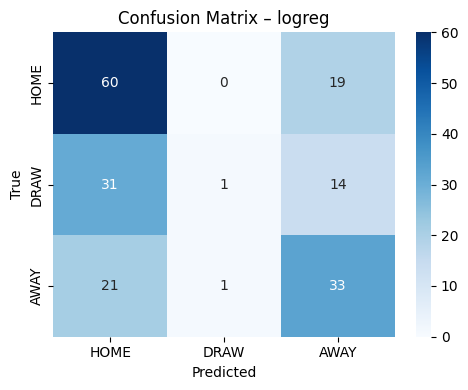

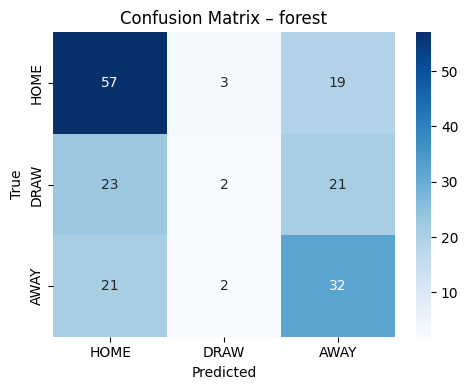

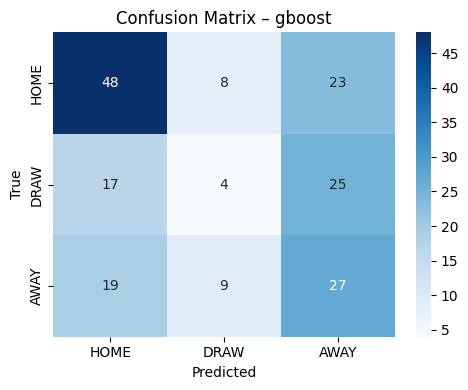

,model,accuracy,log_loss,brier_score
1,forest,0.505556,1.037205,0.206462
0,logreg,0.522222,1.046423,0.208494
2,gboost,0.438889,1.084231,0.219148


In [16]:
import seaborn as sns

results1=[]

for name, model in pipelines3.items():
    
    # ---- Train ----
    model.fit(X_train, y_train)
    
    # ---- Predict ----
    y_pred = model.predict(X_valid)
    y_proba = model.predict_proba(X_valid)

    # ---- Metrics ----
    acc = accuracy_score(y_valid, y_pred)
    ll  = log_loss(y_valid, y_proba)
    
    # Brier multi-classe = moyenne des Brier par classe
    brier = np.mean([
        brier_score_loss((y_valid == c).astype(int), y_proba[:, idx])
        for idx, c in enumerate(model.classes_)
    ])
    
    results1.append({
        "model": name,
        "accuracy": acc,
        "log_loss": ll,
        "brier_score": brier
    })
    
    cm = confusion_matrix(y_valid, y_pred, labels=["HOME_TEAM", "DRAW", "AWAY_TEAM"])

    plt.figure(figsize=(5,4))  # ← nouvelle figure à chaque boucle
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["HOME", "DRAW", "AWAY"],
                yticklabels=["HOME", "DRAW", "AWAY"])
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()



# ---- Summary table ----
df_results = pd.DataFrame(results1)
display(df_results.sort_values("log_loss"))

## Calibrated

In [17]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_pipelines3 = {}
for name, pipe in pipelines3.items():
    calibrated_pipelines3[name] = CalibratedClassifierCV(pipe, cv=5, method='isotonic')

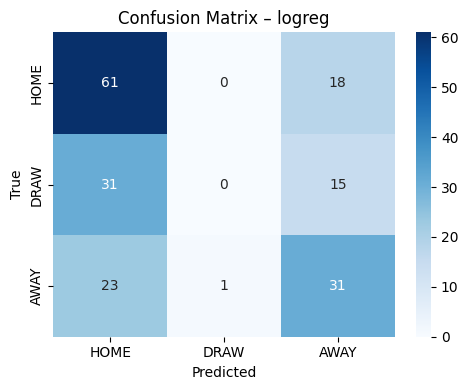

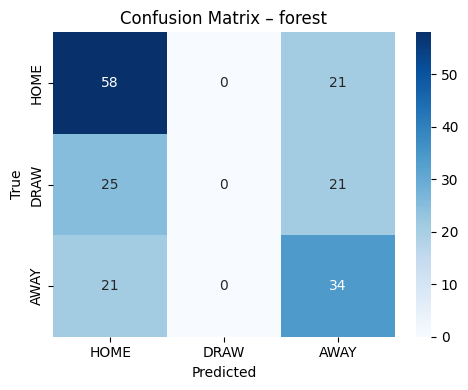

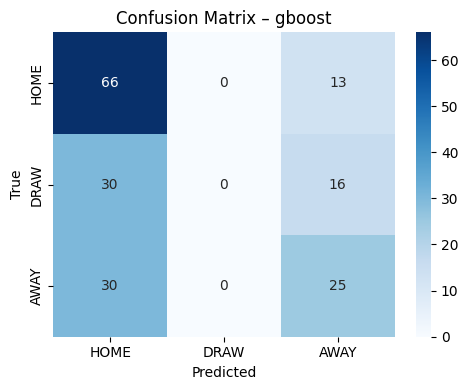

,model,accuracy,log_loss,brier_score
1,forest,0.511111,1.031986,0.205964
2,gboost,0.505556,1.045945,0.208528
0,logreg,0.511111,1.226044,0.207917


In [18]:
results3_cal=[]

for name, model in calibrated_pipelines3.items():
    
    # ---- Train ----
    model.fit(X_train, y_train)
    
    # ---- Predict ----
    y_pred = model.predict(X_valid)
    y_proba = model.predict_proba(X_valid)

    # ---- Metrics ----
    acc = accuracy_score(y_valid, y_pred)
    ll  = log_loss(y_valid, y_proba)
    
    # Brier multi-classe = moyenne des Brier par classe
    brier = np.mean([
        brier_score_loss((y_valid == c).astype(int), y_proba[:, idx])
        for idx, c in enumerate(model.classes_)
    ])
    
    results3_cal.append({
        "model": name,
        "accuracy": acc,
        "log_loss": ll,
        "brier_score": brier
    })
    
    cm = confusion_matrix(y_valid, y_pred, labels=["HOME_TEAM", "DRAW", "AWAY_TEAM"])

    plt.figure(figsize=(5,4))  # ← nouvelle figure à chaque boucle
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["HOME", "DRAW", "AWAY"],
                yticklabels=["HOME", "DRAW", "AWAY"])
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()



# ---- Summary table ----
df_results = pd.DataFrame(results3_cal)
display(df_results.sort_values("log_loss"))


## Fine tuning

In [19]:
from sklearn.model_selection import GridSearchCV


In [20]:
lr_params={
    'logisticregression__C':[0.01,0.1,1,10],
    'logisticregression__penalty':['l2'],
    'logisticregression__solver':  ['lbfgs']
}

rf_params = {
    'randomforestclassifier__n_estimators': [200, 500],
    'randomforestclassifier__max_depth': [None, 10],
    'randomforestclassifier__min_samples_leaf': [1, 4]
}

gb_params = {
    'gradientboostingclassifier__n_estimators': [100, 200],
    'gradientboostingclassifier__learning_rate': [0.05,0.1],
    'gradientboostingclassifier__max_depth': [3, 5],
}

params={
    'logreg':lr_params,
    'forest':rf_params,
    'gboost':gb_params
}




In [21]:
fitted_models3={}
for name, estimator in pipelines3.items():
    print("fitting model:",name)
    model=GridSearchCV(estimator,
                       param_grid=params[name],
                       cv=3,scoring='neg_log_loss')
    model.fit(X_train,y_train)
    fitted_models3[name]=model


fitting model: logreg
fitting model: forest
fitting model: gboost


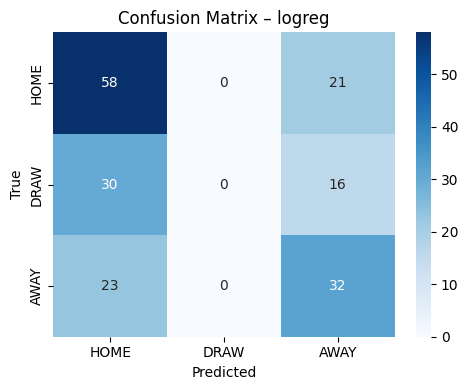

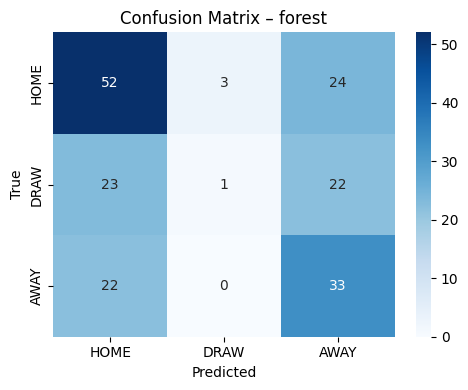

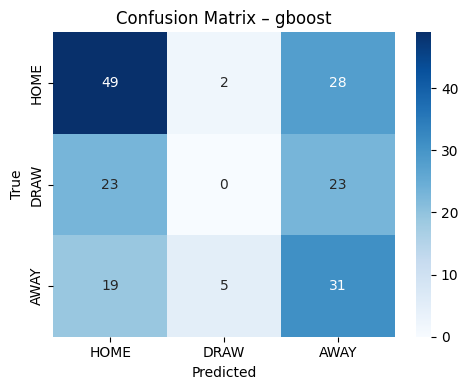

,model,accuracy,log_loss,brier_score
0,logreg,0.500000,1.033591,0.205839
2,gboost,0.444444,1.043003,0.209534
1,forest,0.477778,1.054226,0.210029


In [22]:
results3_grid=[]
for name, model in fitted_models3.items():
    # ---- Predict ----
    y_pred = model.predict(X_valid)
    y_proba = model.predict_proba(X_valid)

    # ---- Metrics ----
    acc = accuracy_score(y_valid, y_pred)
    ll  = log_loss(y_valid, y_proba)
    
    # Brier multi-classe = moyenne des Brier par classe
    brier = np.mean([
        brier_score_loss((y_valid == c).astype(int), y_proba[:, idx])
        for idx, c in enumerate(model.classes_)
    ])
    
    results3_grid.append({
        "model": name,
        "accuracy": acc,
        "log_loss": ll,
        "brier_score": brier
    })
    
    cm = confusion_matrix(y_valid, y_pred, labels=["HOME_TEAM", "DRAW", "AWAY_TEAM"])

    plt.figure(figsize=(5,4))  # ← nouvelle figure à chaque boucle
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["HOME", "DRAW", "AWAY"],
                yticklabels=["HOME", "DRAW", "AWAY"])
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

df_results = pd.DataFrame(results3_grid)
display(df_results.sort_values("log_loss"))


## isotonic fine tuning

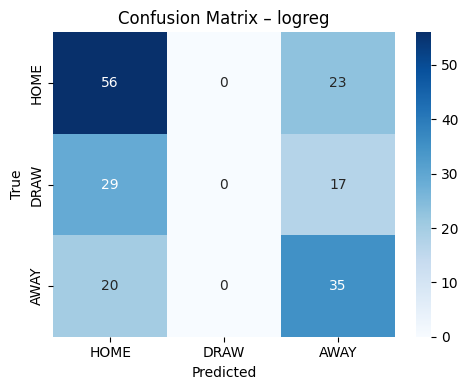

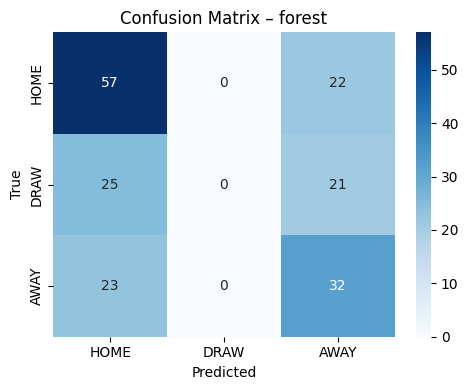

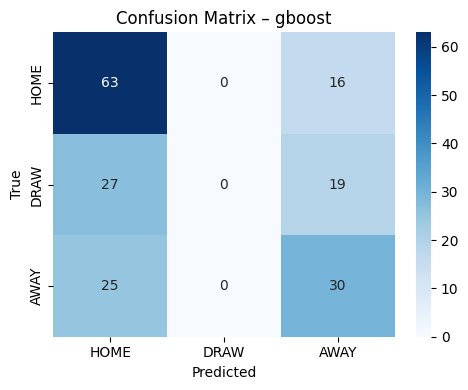

,model,accuracy,log_loss,brier_score
2,gboost,0.516667,1.019605,0.203194
1,forest,0.494444,1.027333,0.204711
0,logreg,0.505556,1.061680,0.208240


In [23]:
results3_grid_cal=[]
for name, model in fitted_models3.items():
    # ---- Predict ----
    calibrated = CalibratedClassifierCV(model.best_estimator_, cv=5, method='isotonic')
    calibrated.fit(X_train, y_train)

    y_pred = calibrated.predict(X_valid)
    y_proba = calibrated.predict_proba(X_valid)

    # ---- Metrics ----
    acc = accuracy_score(y_valid, y_pred)
    ll  = log_loss(y_valid, y_proba)
    
    # Brier multi-classe = moyenne des Brier par classe
    brier = np.mean([
        brier_score_loss((y_valid== c).astype(int), y_proba[:, idx])
        for idx, c in enumerate(calibrated.classes_)
    ])
    
    results3_grid_cal.append({
        "model": name,
        "accuracy": acc,
        "log_loss": ll,
        "brier_score": brier
    })
    
    cm = confusion_matrix(y_valid, y_pred, labels=["HOME_TEAM", "DRAW", "AWAY_TEAM"])

    plt.figure(figsize=(5,4))  # ← nouvelle figure à chaque boucle
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["HOME", "DRAW", "AWAY"],
                yticklabels=["HOME", "DRAW", "AWAY"])
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

df_results = pd.DataFrame(results3_grid_cal)
display(df_results.sort_values("log_loss"))


## Variables redondantes?

In [24]:
best_model=CalibratedClassifierCV(fitted_models3["gboost"].best_estimator_, cv=5, method='isotonic')
best_model.fit(X_train,y_train)

,estimator,Pipeline(step..._rate=0.05))])
,method,'isotonic'
,cv,5
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [25]:
from sklearn.inspection import permutation_importance

r = permutation_importance(best_model, X_valid, y_valid, n_repeats=40, random_state=42)
importance = pd.DataFrame({
    "feature": X_valid.columns,
    "importance": r.importances_mean
}).sort_values(by="importance", ascending=False)

print(importance)

                         feature  importance
17                dif_elo_before    0.046111
13              dif_avg_goal_for    0.038194
8         away_avg_goals_against    0.026528
4            home_home_loss_rate    0.026111
15                  dif_win_rate    0.025000
3             home_home_win_rate    0.023056
1             home_avg_goals_for    0.020972
11               away_elo_before    0.019722
0   home_avg_points_before_match    0.017917
2         home_avg_goals_against    0.015972
9             away_away_win_rate    0.013611
7             away_avg_goals_for    0.012917
12                dif_avg_points    0.012917
16                 dif_loss_rate    0.012083
10           away_away_loss_rate    0.008333
5                home_elo_before    0.007639
6   away_avg_points_before_match    0.005278
14          dif_avg_goal_against    0.004306


In [26]:
remove_features=["away_away_loss_rate","dif_avg_points","dif_avg_goal_against","away_avg_points_before_match"]

In [27]:
X_train4=X_train.drop(columns=remove_features)
X_valid4=X_valid.drop(columns=remove_features)

In [28]:
X_valid4.columns

Index(['home_avg_points_before_match', 'home_avg_goals_for',
       'home_avg_goals_against', 'home_home_win_rate', 'home_home_loss_rate',
       'home_elo_before', 'away_avg_goals_for', 'away_avg_goals_against',
       'away_away_win_rate', 'away_elo_before', 'dif_avg_goal_for',
       'dif_win_rate', 'dif_loss_rate', 'dif_elo_before'],
      dtype='object')

In [29]:
num_features4 = ['home_avg_points_before_match', 'home_avg_goals_for',
       'home_avg_goals_against', 'home_home_win_rate', 'home_home_loss_rate',
       'home_elo_before', 'away_avg_goals_for', 'away_avg_goals_against',
       'away_away_win_rate', 'away_elo_before', 'dif_avg_goal_for',
       'dif_win_rate', 'dif_loss_rate', 'dif_elo_before']

preprocessor4 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features4)
    ]
)
pipelines4={
    'logreg': make_pipeline(preprocessor4,LogisticRegression(max_iter=1000,solver='lbfgs')),
    'forest':make_pipeline(preprocessor4,RandomForestClassifier()),
    'gboost':make_pipeline(preprocessor4,GradientBoostingClassifier())
}

## fine tuning

In [30]:
fitted_models4={}
for name, estimator in pipelines4.items():
    print("fitting model:",name)
    model=GridSearchCV(estimator,
                       param_grid=params[name],
                       cv=3,scoring='neg_log_loss')
    model.fit(X_train4,y_train)
    fitted_models4[name]=model
    

fitting model: logreg
fitting model: forest
fitting model: gboost


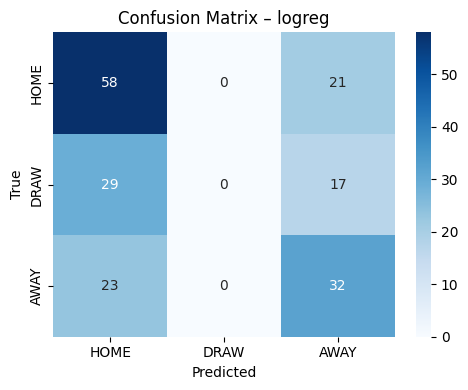

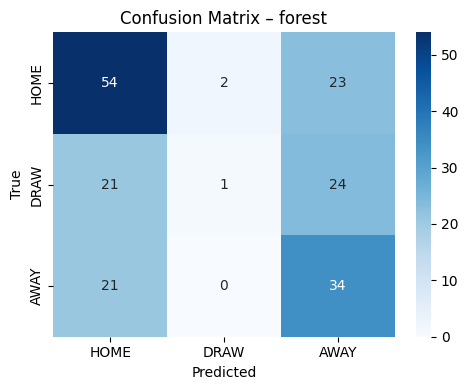

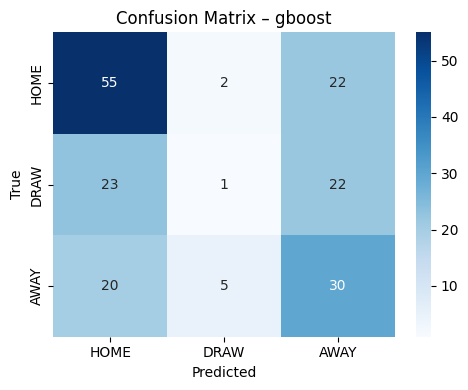

,model,accuracy,log_loss,brier_score
0,logreg,0.500000,1.034527,0.206123
1,forest,0.494444,1.048234,0.209291
2,gboost,0.477778,1.061532,0.212518


In [31]:
results4_grid=[]
for name, model in fitted_models4.items():
    # ---- Predict ----
    y_pred = model.predict(X_valid4)
    y_proba = model.predict_proba(X_valid4)

    # ---- Metrics ----
    acc = accuracy_score(y_valid, y_pred)
    ll  = log_loss(y_valid, y_proba)
    
    # Brier multi-classe = moyenne des Brier par classe
    brier = np.mean([
        brier_score_loss((y_valid == c).astype(int), y_proba[:, idx])
        for idx, c in enumerate(model.classes_)
    ])
    
    results4_grid.append({
        "model": name,
        "accuracy": acc,
        "log_loss": ll,
        "brier_score": brier
    })
    
    cm = confusion_matrix(y_valid, y_pred, labels=["HOME_TEAM", "DRAW", "AWAY_TEAM"])

    plt.figure(figsize=(5,4))  # ← nouvelle figure à chaque boucle
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["HOME", "DRAW", "AWAY"],
                yticklabels=["HOME", "DRAW", "AWAY"])
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

df_results = pd.DataFrame(results4_grid)
display(df_results.sort_values("log_loss"))


## calibration

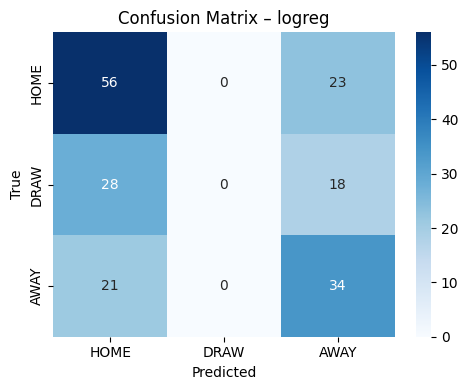

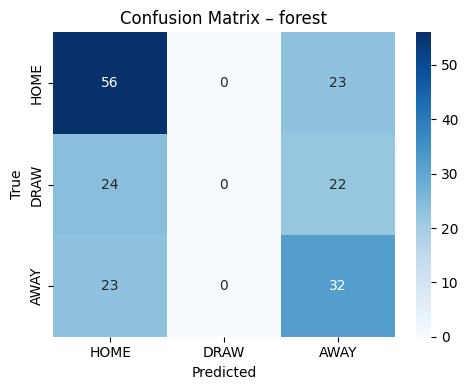

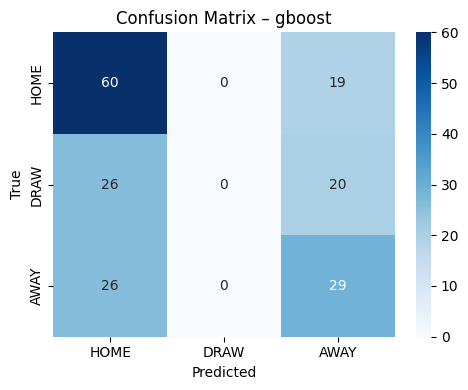

,model,accuracy,log_loss,brier_score
1,forest,0.488889,1.036742,0.207573
2,gboost,0.494444,1.044011,0.207479
0,logreg,0.500000,1.064259,0.209760


In [32]:

results4_grid_cal=[]
for name, model in fitted_models4.items():
    # ---- Predict ----
    calibrated = CalibratedClassifierCV(model.best_estimator_, cv=5, method='isotonic')
    calibrated.fit(X_train4, y_train)

    y_pred = calibrated.predict(X_valid4)
    y_proba = calibrated.predict_proba(X_valid4)

    # ---- Metrics ----
    acc = accuracy_score(y_valid, y_pred)
    ll  = log_loss(y_valid, y_proba)
    
    # Brier multi-classe = moyenne des Brier par classe
    brier = np.mean([
        brier_score_loss((y_valid == c).astype(int), y_proba[:, idx])
        for idx, c in enumerate(calibrated.classes_)
    ])
    
    results4_grid_cal.append({
        "model": name,
        "accuracy": acc,
        "log_loss": ll,
        "brier_score": brier
    })
    
    cm = confusion_matrix(y_valid, y_pred, labels=["HOME_TEAM", "DRAW", "AWAY_TEAM"])

    plt.figure(figsize=(5,4))  # ← nouvelle figure à chaque boucle
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["HOME", "DRAW", "AWAY"],
                yticklabels=["HOME", "DRAW", "AWAY"])
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

df_results = pd.DataFrame(results4_grid_cal)
display(df_results.sort_values("log_loss"))



In [33]:
best_model_bis=CalibratedClassifierCV(fitted_models4["gboost"].best_estimator_, cv=5, method='isotonic')
best_model_bis.fit(X_train4,y_train)

,estimator,Pipeline(step..._rate=0.05))])
,method,'isotonic'
,cv,5
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [34]:
r = permutation_importance(best_model_bis, X_valid4, y_valid, n_repeats=40, random_state=42)
importance = pd.DataFrame({
    "feature": X_valid4.columns,
    "importance": r.importances_mean
}).sort_values(by="importance", ascending=False)

print(importance)

                         feature  importance
13                dif_elo_before    0.018889
4            home_home_loss_rate    0.002222
2         home_avg_goals_against   -0.000139
10              dif_avg_goal_for   -0.001389
0   home_avg_points_before_match   -0.005833
3             home_home_win_rate   -0.006389
7         away_avg_goals_against   -0.011389
11                  dif_win_rate   -0.012083
12                 dif_loss_rate   -0.012778
6             away_avg_goals_for   -0.014167
8             away_away_win_rate   -0.014306
5                home_elo_before   -0.014444
9                away_elo_before   -0.019028
1             home_avg_goals_for   -0.020139


In [35]:
remove_features2=["home_home_win_rate","dif_loss_rate","dif_win_rate","away_avg_goals_for","away_away_win_rate","home_elo_before","home_avg_goals_for","away_elo_before"]

In [36]:
X_train5=X_train4.drop(columns=remove_features2)
X_valid5=X_valid4.drop(columns=remove_features2)

In [37]:
X_valid5.columns

Index(['home_avg_points_before_match', 'home_avg_goals_against',
       'home_home_loss_rate', 'away_avg_goals_against', 'dif_avg_goal_for',
       'dif_elo_before'],
      dtype='object')

In [38]:
num_features5 = ['home_avg_points_before_match', 'home_avg_goals_against',
       'home_home_loss_rate', 'away_avg_goals_against', 'dif_avg_goal_for',
       'dif_elo_before']

preprocessor5 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features5)
    ]
)
pipelines5={
    'logreg': make_pipeline(preprocessor5,LogisticRegression(max_iter=1000,solver='lbfgs')),
    'forest':make_pipeline(preprocessor5,RandomForestClassifier()),
    'gboost':make_pipeline(preprocessor5,GradientBoostingClassifier())
}

## Fitted model fine tuning

In [40]:
fitted_models5={}
for name, estimator in pipelines5.items():
    print("fitting model:",name)
    model=GridSearchCV(estimator,
                       param_grid=params[name],
                       cv=3,scoring='neg_log_loss')
    model.fit(X_train5,y_train)
    fitted_models5[name]=model
    

fitting model: logreg
fitting model: forest
fitting model: gboost


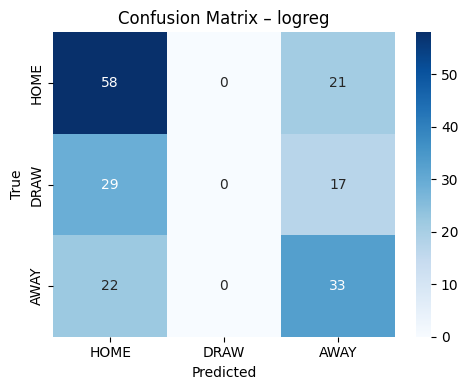

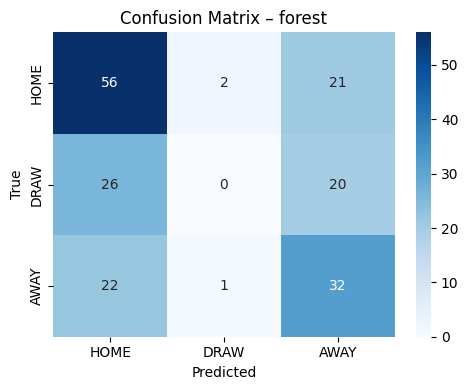

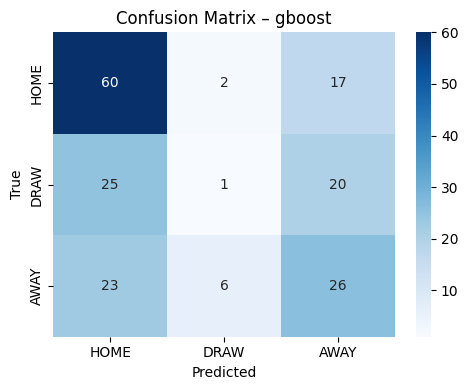

,model,accuracy,log_loss,brier_score
0,logreg,0.505556,1.027233,0.204248
1,forest,0.488889,1.028367,0.204173
2,gboost,0.483333,1.061388,0.210640


In [41]:
results5_grid=[]
for name, model in fitted_models5.items():
    # ---- Predict ----
    y_pred = model.predict(X_valid5)
    y_proba = model.predict_proba(X_valid5)

    # ---- Metrics ----
    acc = accuracy_score(y_valid, y_pred)
    ll  = log_loss(y_valid, y_proba)
    
    # Brier multi-classe = moyenne des Brier par classe
    brier = np.mean([
        brier_score_loss((y_valid == c).astype(int), y_proba[:, idx])
        for idx, c in enumerate(model.classes_)
    ])
    
    results5_grid.append({
        "model": name,
        "accuracy": acc,
        "log_loss": ll,
        "brier_score": brier
    })
    
    cm = confusion_matrix(y_valid, y_pred, labels=["HOME_TEAM", "DRAW", "AWAY_TEAM"])

    plt.figure(figsize=(5,4))  # ← nouvelle figure à chaque boucle
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["HOME", "DRAW", "AWAY"],
                yticklabels=["HOME", "DRAW", "AWAY"])
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

df_results = pd.DataFrame(results5_grid)
display(df_results.sort_values("log_loss"))


## calibration

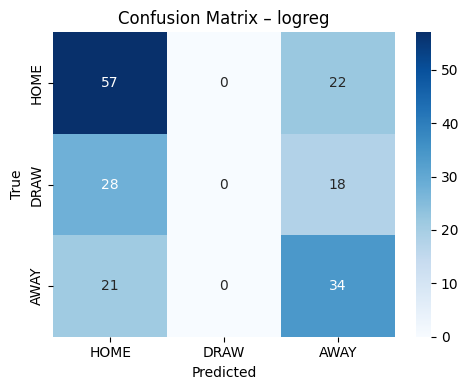

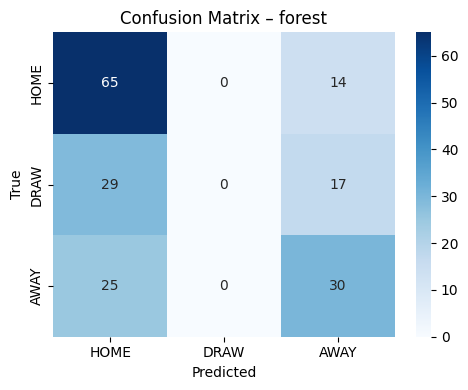

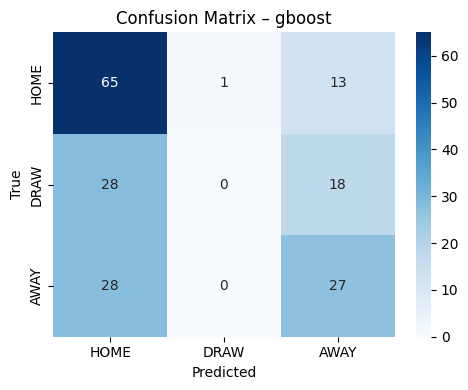

,model,accuracy,log_loss,brier_score
1,forest,0.527778,1.007279,0.200120
2,gboost,0.511111,1.042734,0.206210
0,logreg,0.505556,1.249084,0.209202


In [42]:

results5_grid_cal=[]
for name, model in fitted_models5.items():
    # ---- Predict ----
    calibrated = CalibratedClassifierCV(model.best_estimator_, cv=5, method='isotonic')
    calibrated.fit(X_train5, y_train)

    y_pred = calibrated.predict(X_valid5)
    y_proba = calibrated.predict_proba(X_valid5)

    # ---- Metrics ----
    acc = accuracy_score(y_valid, y_pred)
    ll  = log_loss(y_valid, y_proba)
    
    # Brier multi-classe = moyenne des Brier par classe
    brier = np.mean([
        brier_score_loss((y_valid == c).astype(int), y_proba[:, idx])
        for idx, c in enumerate(calibrated.classes_)
    ])
    
    results5_grid_cal.append({
        "model": name,
        "accuracy": acc,
        "log_loss": ll,
        "brier_score": brier
    })
    
    cm = confusion_matrix(y_valid, y_pred, labels=["HOME_TEAM", "DRAW", "AWAY_TEAM"])

    plt.figure(figsize=(5,4))  # ← nouvelle figure à chaque boucle
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["HOME", "DRAW", "AWAY"],
                yticklabels=["HOME", "DRAW", "AWAY"])
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

df_results = pd.DataFrame(results5_grid_cal)
display(df_results.sort_values("log_loss"))



In [43]:
best_model_ter=CalibratedClassifierCV(fitted_models5["forest"].best_estimator_, cv=5, method='isotonic')
best_model_ter.fit(X_train5,y_train)

,estimator,Pipeline(step...mators=500))])
,method,'isotonic'
,cv,5
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [44]:
r = permutation_importance(best_model_ter, X_valid5, y_valid, n_repeats=40, random_state=42)
importance = pd.DataFrame({
    "feature": X_valid5.columns,
    "importance": r.importances_mean
}).sort_values(by="importance", ascending=False)

print(importance)

                        feature  importance
5                dif_elo_before    0.037917
4              dif_avg_goal_for    0.022639
3        away_avg_goals_against    0.009583
1        home_avg_goals_against    0.007500
0  home_avg_points_before_match   -0.000556
2           home_home_loss_rate   -0.001389


# Part 2: prediction

In [111]:
def prepa_donnee_elo_short(df,history):

    df=df[["status","season.startDate","matchday","homeTeam.id","homeTeam.name","homeTeam.tla","awayTeam.id","awayTeam.name","awayTeam.tla",
                        "score.winner","score.fullTime.home","score.fullTime.away"]]

    df = df.sort_values(["matchday", "homeTeam.id"])

    df_home = df[["matchday", "homeTeam.id", "homeTeam.tla", "season.startDate",
                "score.fullTime.home", "score.fullTime.away", "score.winner"]].rename(
        columns={
            "homeTeam.id": "team_id",
            "homeTeam.tla": "team",
            "season.startDate": "season",
            "score.fullTime.home": "goals_for",
            "score.fullTime.away": "goals_against"
        }
    )
    df_home["is_home"] = True

    df_away = df[["matchday", "awayTeam.id", "awayTeam.tla", "season.startDate",
                "score.fullTime.home", "score.fullTime.away", "score.winner"]].rename(
        columns={
            "awayTeam.id": "team_id",
            "awayTeam.tla": "team",
            "season.startDate": "season",
            "score.fullTime.home": "goals_against",
            "score.fullTime.away": "goals_for"
        }
    )
    df_away["is_home"] = False

    df_home["win"]  = df_home["score.winner"] == "HOME_TEAM"
    df_home["loss"] = df_home["score.winner"] == "AWAY_TEAM"

    df_away["win"]  = df_away["score.winner"] == "AWAY_TEAM"
    df_away["loss"] = df_away["score.winner"] == "HOME_TEAM"

    df_long = pd.concat([df_home, df_away], ignore_index=True)
    df_long=pd.merge(df_long,history,on=["season","matchday","team"],how="left")

    df_long = df_long.sort_values(["team_id", "matchday"])
    df_long["points"] = df_long.apply(pts, axis=1)
    df_long["points_before_match"] = (
        df_long.groupby("team_id")["points"]
            .cumsum()
            .shift(1)
    )


    df_long["avg_points_before_match"] = (
        df_long["points_before_match"]/(df_long["matchday"]-1)
    )

    df_long["goal_diff"] = df_long["goals_for"] - df_long["goals_against"]


    df_long["avg_goals_for"] = df_long.groupby("team_id")["goals_for"] \
                                    .transform(lambda s: s.shift(1).expanding().mean())

    df_long["avg_goals_against"] = df_long.groupby("team_id")["goals_against"] \
                                        .transform(lambda s: s.shift(1).expanding().mean())

    df_long["cum_goals_for"] = (
        df_long.groupby("team_id")["goals_for"].cumsum().shift(1)
    )
    df_long["cum_goals_against"] = (
        df_long.groupby("team_id")["goals_against"].cumsum().shift(1)
    )
    df_long["cum_goal_diff"] = df_long["cum_goals_for"] - df_long["cum_goals_against"]


    df_long["home_win_rate"] = (
        df_long[df_long.is_home]
        .groupby("team_id")["win"]
        .transform(lambda s: s.shift(1).expanding().mean())
    )

    df_long["away_win_rate"] = (
        df_long[~df_long.is_home]
        .groupby("team_id")["win"]
        .transform(lambda s: s.shift(1).expanding().mean())
    )

    df_long["away_loss_rate"] = (
        df_long[~df_long.is_home]
        .groupby("team_id")["loss"]
        .transform(lambda s: s.shift(1).expanding().mean())
    )

    df_long["home_loss_rate"] = (
        df_long[df_long.is_home]
        .groupby("team_id")["loss"]
        .transform(lambda s: s.shift(1).expanding().mean())
    )


    df_long = df_long.sort_values(
        ["matchday", "points_before_match", "cum_goal_diff", "cum_goals_for"],
        ascending=[True, False, False, False]
    )

    # On calcule le ranking par matchday en utilisant cumcount
    df_long["ranking_before_match"] = (
        df_long.groupby("matchday").cumcount() + 1
    )

    df_long["form_last5"] = (
        df_long.groupby("team_id")["points"]
            .transform(lambda s: s.shift(1).rolling(5, min_periods=1).sum())
    )


    cols_to_fill = [
        "elo_before",
        "avg_goals_for",
        "avg_goals_against",
        "avg_points_before_match",
        "home_loss_rate"
    ]

    df_long = df_long.sort_values(["team", "matchday"])

    df_long[cols_to_fill] = (
        df_long
        .groupby("team")[cols_to_fill]
        .ffill()
    )

    df_stats=df_long[["team_id", "matchday","avg_points_before_match", "cum_goal_diff", "cum_goals_for", "cum_goals_against",
    "avg_goals_for", "avg_goals_against",
    "home_win_rate", "away_win_rate", "home_loss_rate", "away_loss_rate",
    "ranking_before_match", "form_last5","elo_before"]]
    df_merged = df\
    .merge(
        df_stats.add_prefix("home_"),
        left_on=["homeTeam.id", "matchday"],
        right_on=["home_team_id", "home_matchday"],
        how="left"
    )\
    .merge(
        df_stats.add_prefix("away_"),
        left_on=["awayTeam.id", "matchday"],
        right_on=["away_team_id", "away_matchday"],
        how="left"
    )

    df_merged['dif_avg_goal_for']=df_merged['home_avg_goals_for']-df_merged['away_avg_goals_for']
    df_merged['dif_elo_before']=df_merged['home_elo_before']-df_merged['away_elo_before']

    df_merged.drop(columns=["season.startDate","status","homeTeam.name","awayTeam.name",
        "home_team_id", "home_matchday", 
        "away_team_id", "away_matchday","score.fullTime.home","score.fullTime.away",
        "home_away_win_rate","home_away_loss_rate","away_home_win_rate","away_home_loss_rate",
        "home_cum_goal_diff","away_cum_goal_diff","home_cum_goals_for","away_cum_goals_for",
        "home_cum_goals_against","away_cum_goals_against",'homeTeam.tla', 'awayTeam.tla','home_avg_goals_for','home_home_win_rate',
        'home_ranking_before_match','home_form_last5','home_elo_before','away_avg_points_before_match','away_avg_goals_for','away_away_win_rate','away_away_loss_rate',
        'away_ranking_before_match', 'away_form_last5', 'away_elo_before'
    ],inplace=True)

    return df_merged

In [112]:
df_for_validation=prepa_donnee_elo_short(df_matches_2025,history)

df_for_validation.columns

Index(['matchday', 'homeTeam.id', 'awayTeam.id', 'score.winner',
       'home_avg_points_before_match', 'home_avg_goals_against',
       'home_home_loss_rate', 'away_avg_goals_against', 'dif_avg_goal_for',
       'dif_elo_before'],
      dtype='object')

In [113]:
df_for_validation

,matchday,homeTeam.id,awayTeam.id,score.winner,home_avg_points_before_match,home_avg_goals_against,home_home_loss_rate,away_avg_goals_against,dif_avg_goal_for,dif_elo_before
0,1,512,521,DRAW,inf,NaN,NaN,NaN,NaN,-58.480551
1,1,519,525,HOME_TEAM,inf,NaN,NaN,NaN,NaN,103.001538
2,1,522,511,AWAY_TEAM,inf,NaN,NaN,NaN,NaN,80.462395
3,1,529,516,HOME_TEAM,inf,NaN,NaN,NaN,NaN,-81.514501
4,1,532,1045,HOME_TEAM,inf,NaN,NaN,NaN,NaN,68.089765
...,...,...,...,...,...,...,...,...,...,...
301,34,523,546,None,1.424242,1.074074,0.1875,0.888889,-0.481481,-47.558128
302,34,525,533,None,1.121212,1.518519,0.0625,1.296296,0.555556,25.747327
303,34,543,511,None,0.515152,1.730769,0.6250,1.185185,-0.484330,-112.044767
304,34,576,548,None,1.212121,1.222222,0.1875,1.407407,-0.148148,-53.364754


In [ ]:


df_for_validation=df_for_validation[df_for_validation.matchday<=25]

X_valid=df_for_validation.drop(columns=["matchday","score.winner","home_ranking_before_match","away_ranking_before_match",
                                    "dif_ranking","rate_elo_before",'home_form_last5','away_form_last5','dif_form_last5'])
y_valid=df_for_validation["score.winner"]